In [ ]:
# convert fil to h5
# Load the filterbank file
fb = Waterfall('/datax/scratch/jaym/data0005-beam0000.fil', load_data=True)

# Force data load to avoid memmap
_ = fb.data

# Now save as HDF5
fb.write_to_hdf5('/datax/scratch/jaym/data0005-beam0000.h5')

blimpy.waterfall INFO     __write_to_hdf5_light: Writing the spectra matrix for /datax/scratch/jaym/data0005-beam0000.h5 without blobbing.
hdf5plugin._filters WARNING  Deprecation: hdf5plugin.Bitshuffle's lz4 argument is deprecated, use cname='lz4' or 'none' instead.
hdf5plugin._filters WARNING  Deprecation: hdf5plugin.Bitshuffle's lz4 argument is deprecated, use cname='lz4' or 'none' instead.
blimpy.waterfall INFO     Conversion time: 3.05sec


In [4]:
# imports
import matplotlib.pyplot as plt
from blimpy import Waterfall
from setigen.split_utils import split_fil
import setigen as stg
import astropy.units as u
import numpy as np
import h5py
import os

%matplotlib inline

In [5]:
fb = Waterfall('/datax/scratch/jaym/data0005-beam0000.h5')

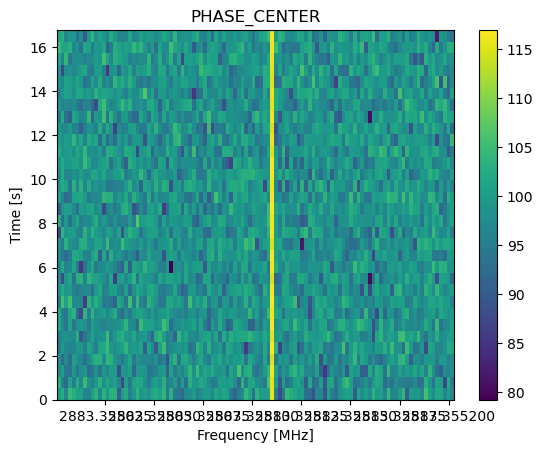

In [6]:
fb.plot_waterfall(2883.3550,2883.3552)

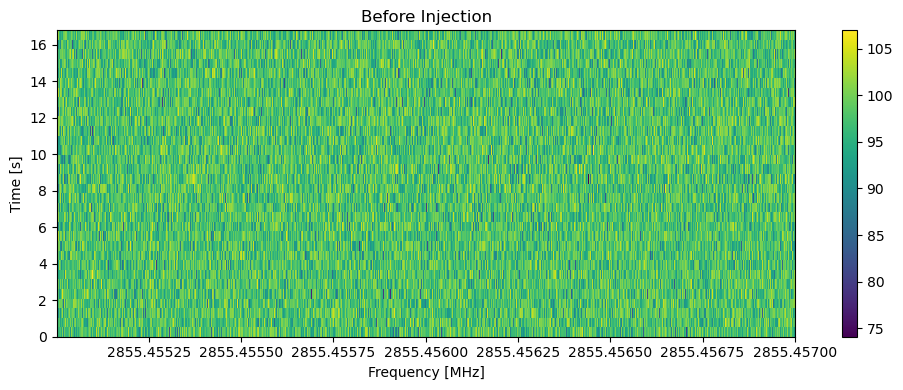

In [7]:
# Plot before injection
plt.figure(figsize=(10, 4))
fb.plot_waterfall(2855.455,2855.457)
plt.title('Before Injection')
plt.tight_layout()

In [8]:
frame = stg.Frame(waterfall="/datax/scratch/jaym/data0005-beam0000.h5")

In [9]:
frame.add_signal(
    stg.constant_path(f_start=2855.456*u.MHz,
    drift_rate=2*u.Hz/u.s),
    stg.constant_t_profile(level=frame.get_intensity(snr=30)),
    stg.gaussian_f_profile(width=2*u.Hz),
    stg.constant_bp_profile(level=1)
)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(32, 16777216))

In [10]:
frame.save_h5('/datax/scratch/jaym/data0005-beam0000-injected.h5')

blimpy.waterfall INFO     __write_to_hdf5_light: Writing the spectra matrix for /datax/scratch/jaym/data0005-beam0000-injected.h5 without blobbing.
hdf5plugin._filters WARNING  Deprecation: hdf5plugin.Bitshuffle's lz4 argument is deprecated, use cname='lz4' or 'none' instead.
hdf5plugin._filters WARNING  Deprecation: hdf5plugin.Bitshuffle's lz4 argument is deprecated, use cname='lz4' or 'none' instead.
blimpy.waterfall INFO     Conversion time: 3.87sec


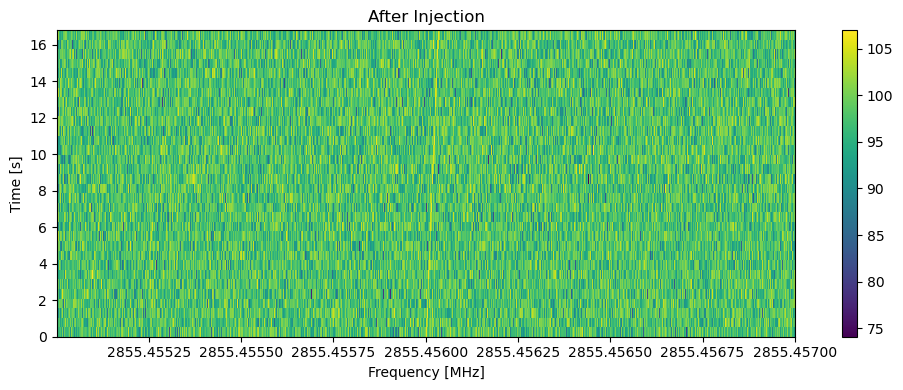

In [11]:
injected_fb = Waterfall('/datax/scratch/jaym/data0005-beam0000-injected.h5')

plt.figure(figsize=(10, 4))
injected_fb.plot_waterfall(2855.455,2855.457)
plt.title('After Injection')
plt.tight_layout()

In [2]:
!seticore

usage: seticore [input]
seticore version: 1.0.6
seticore options:
  -h [ --help ]                produce help message
  --input arg                  alternate way of setting the input file(s) or 
                               directory
  --output arg                 the output as .dat file, .hits file, or 
                               directory. defaults to <input>.dat
  -M [ --max_drift ] arg (=10) maximum absolute value of drift, in Hz/sec
  -m [ --min_drift ] arg       minimum absolute value of drift, in Hz/sec. 
                               Using this is discouraged.
  -s [ --snr ] arg (=25)       minimum SNR to report a hit
  --recipe_dir arg             the directory to find beamforming recipes in. 
                               set this to beamform.
  --recipe arg                 the beamforming recipe file. set this to 
                               beamform.
  --h5_dir arg                 optional directory to save .h5 files containing 
                               po

In [12]:
!seticore --input "/datax/scratch/jaym/data0005-beam0000.h5" --output "seticore_output/cosmic_file.dat"
!seticore --input "/datax/scratch/jaym/data0005-beam0000-injected-full.h5" --output "seticore_output/cosmic_file_injected.dat"

welcome to seticore, version 1.0.6
running in dedoppler mode.
loading input from /datax/scratch/jaym/data0005-beam0000.h5
dedoppler parameters: max_drift=10.00 min_drift=0.0000 snr=25.00
writing output to seticore_output/cosmic_file.dat
hit: coarse channel = 0, index = 33609, snr = 60.03456, drift rate = -0.00000 (0 bins)
hit: coarse channel = 0, index = 45560, snr = 49.98223, drift rate = -0.00000 (0 bins)
hit: coarse channel = 0, index = 63792, snr = 27.26885, drift rate = 0.11735 (-1 bin)
hit: coarse channel = 0, index = 75964, snr = 153.83780, drift rate = -0.00000 (0 bins)
hit: coarse channel = 0, index = 91068, snr = 54.64148, drift rate = -0.00000 (0 bins)
hit: coarse channel = 0, index = 97542, snr = 46.50642, drift rate = -0.23471 (2 bins)
hit: coarse channel = 0, index = 104907, snr = 173.07935, drift rate = -0.00000 (0 bins)
hit: coarse channel = 0, index = 121681, snr = 39.94947, drift rate = -0.00000 (0 bins)
hit: coarse channel = 0, index = 135842, snr = 259.03677, drift 